In [1]:
#| echo: false
#| message: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('cleaned_inflation_with_calculations.csv')

# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract year and month for analysis
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df['Month_Name'] = df['time'].dt.strftime('%b')

# Calculate year-on-year percentage change for CPI
df['CPI_YoY'] = df['Consumer Price Index'].pct_change(12) * 100

# Calculate month-on-month percentage change for CPI
df['CPI_MoM'] = df['Consumer Price Index'].pct_change(1) * 100

# Sort the dataframe by time
df = df.sort_values('time').reset_index(drop=True)

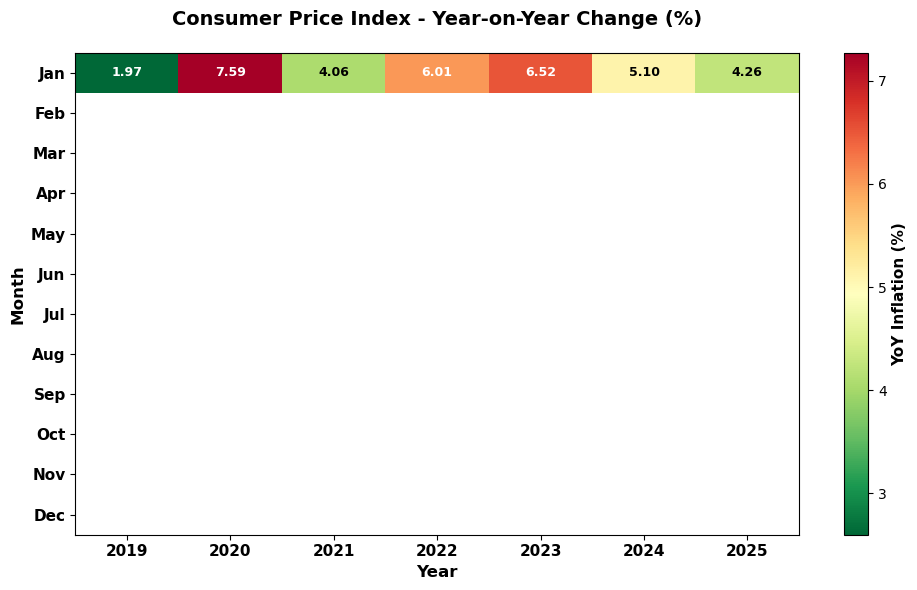

In [4]:
# Calculate YoY and MoM on the full dataframe first
df['CPI_YoY'] = df['Consumer Price Index'].pct_change(12) * 100
df['CPI_MoM'] = df['Consumer Price Index'].pct_change(1) * 100

# Filter data for the last 7 years
current_year = df['Year'].max()
df_last_7_years = df[df['Year'] >= current_year - 6].copy()

# Create pivot table for YoY heatmap
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

yoy_pivot = df_last_7_years.pivot_table(
    values='CPI_YoY', 
    index='Month', 
    columns='Year',
    aggfunc='first'
)

# Reindex to ensure all 12 months
yoy_pivot = yoy_pivot.reindex(index=range(1, 13))

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(10, 6))
vals = yoy_pivot.values

# Dynamic color scaling based on percentiles
finite_vals = vals[np.isfinite(vals)]
if finite_vals.size > 0:
    vmin = np.nanpercentile(finite_vals, 5)
    vmax = np.nanpercentile(finite_vals, 95)
else:
    vmin, vmax = -5, 5

# Create heatmap
im = ax.imshow(vals, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)

# Set ticks and labels
ax.set_xticks(range(yoy_pivot.shape[1]))
ax.set_xticklabels(yoy_pivot.columns.astype(str), fontweight='bold', fontsize=11)
ax.set_yticks(range(12))
ax.set_yticklabels(month_labels, fontweight='bold', fontsize=11)
ax.set_xlabel('Year', fontweight='bold', fontsize=12)
ax.set_ylabel('Month', fontweight='bold', fontsize=12)
ax.set_title('Consumer Price Index - Year-on-Year Change (%)', 
             fontweight='bold', fontsize=14, pad=20)

# Annotate cells with values
for i in range(yoy_pivot.shape[0]):
    for j in range(yoy_pivot.shape[1]):
        val = yoy_pivot.values[i, j]
        if not np.isnan(val):
            # Adaptive text color for readability
            color_intensity = (val - vmin) / (vmax - vmin) if vmax != vmin else 0.5
            text_color = 'white' if color_intensity < 0.3 or color_intensity > 0.7 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                   fontsize=9, color=text_color, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('YoY Inflation (%)', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [6]:
# Let's investigate the pivot table
print("YoY Pivot Shape:", yoy_pivot.shape)
print("\nYoY Pivot:\n", yoy_pivot)
print("\nNon-null counts per year:")
print(yoy_pivot.notna().sum())

YoY Pivot Shape: (12, 7)

YoY Pivot:
 Year       2019      2020      2021      2022      2023     2024     2025
Month                                                                    
1      1.972243  7.593123  4.061252  6.014075  6.517803  5.09915  4.25876
2           NaN       NaN       NaN       NaN       NaN      NaN      NaN
3           NaN       NaN       NaN       NaN       NaN      NaN      NaN
4           NaN       NaN       NaN       NaN       NaN      NaN      NaN
5           NaN       NaN       NaN       NaN       NaN      NaN      NaN
6           NaN       NaN       NaN       NaN       NaN      NaN      NaN
7           NaN       NaN       NaN       NaN       NaN      NaN      NaN
8           NaN       NaN       NaN       NaN       NaN      NaN      NaN
9           NaN       NaN       NaN       NaN       NaN      NaN      NaN
10          NaN       NaN       NaN       NaN       NaN      NaN      NaN
11          NaN       NaN       NaN       NaN       NaN      NaN      NaN


In [7]:
# Let's check the last 7 years data
print("Last 7 years data shape:", df_last_7_years.shape)
print("\nFirst few rows:")
print(df_last_7_years[['time', 'Year', 'Month', 'CPI_YoY']].head(20))
print("\nLast few rows:")
print(df_last_7_years[['time', 'Year', 'Month', 'CPI_YoY']].tail(10))

Last 7 years data shape: (82, 346)

First few rows:
          time  Year  Month   CPI_YoY
96  2019-01-01  2019      1  1.972243
97  2019-01-02  2019      1  2.565982
98  2019-01-03  2019      1  2.857143
99  2019-01-04  2019      1  2.990518
100 2019-01-05  2019      1  3.047896
101 2019-01-06  2019      1  3.176895
102 2019-01-07  2019      1  3.147353
103 2019-01-08  2019      1  3.276353
104 2019-01-09  2019      1  3.994294
105 2019-01-10  2019      1  4.619758
106 2019-01-11  2019      1  5.539773
107 2019-01-12  2019      1  7.351892
108 2020-01-01  2020      1  7.593123
109 2020-01-02  2020      1  6.576126
110 2020-01-03  2020      1  5.840456
111 2020-01-04  2020      1  7.223796
112 2020-01-05  2020      1  6.267606
113 2020-01-06  2020      1  6.228132
114 2020-01-07  2020      1  6.726768
115 2020-01-08  2020      1  6.689655

Last few rows:
          time  Year  Month   CPI_YoY
168 2025-01-01  2025      1  4.258760
169 2025-01-02  2025      1  3.606028
170 2025-01-03  2025

In [8]:
# Analyze the main df to find the bug
print("Main DataFrame shape:", df.shape)
print("\n=== First 15 rows of time-related columns ===")
print(df[['time', 'Year', 'Month', 'Month_Name']].head(15))
print("\n=== Last 15 rows ===")
print(df[['time', 'Year', 'Month', 'Month_Name']].tail(15))
print("\n=== Unique years ===")
print(sorted(df['Year'].unique()))
print("\n=== Unique months ===")
print(sorted(df['Month'].unique()))
print("\n=== Value counts by Year and Month ===")
print(df.groupby(['Year', 'Month']).size().head(30))

Main DataFrame shape: (178, 346)

=== First 15 rows of time-related columns ===
         time  Year  Month Month_Name
0  2011-01-01  2011      1        Jan
1  2011-01-02  2011      1        Jan
2  2011-01-03  2011      1        Jan
3  2011-01-04  2011      1        Jan
4  2011-01-05  2011      1        Jan
5  2011-01-06  2011      1        Jan
6  2011-01-07  2011      1        Jan
7  2011-01-08  2011      1        Jan
8  2011-01-09  2011      1        Jan
9  2011-01-10  2011      1        Jan
10 2011-01-11  2011      1        Jan
11 2011-01-12  2011      1        Jan
12 2012-01-01  2012      1        Jan
13 2012-01-02  2012      1        Jan
14 2012-01-03  2012      1        Jan

=== Last 15 rows ===
          time  Year  Month Month_Name
163 2024-01-08  2024      1        Jan
164 2024-01-09  2024      1        Jan
165 2024-01-10  2024      1        Jan
166 2024-01-11  2024      1        Jan
167 2024-01-12  2024      1        Jan
168 2025-01-01  2025      1        Jan
169 2025-01-02  2

In [10]:
# Check the raw CSV data to understand original format
raw_df = pd.read_csv('cleaned_inflation_with_calculations.csv', nrows=20)
print("=== Raw time column (first 20 rows as strings) ===")
print(raw_df['time'].tolist())
print("\n=== Check if all dates are day 01-12 ===")
# Re-read without parsing dates
raw_check = pd.read_csv('cleaned_inflation_with_calculations.csv')
print(f"Total rows in CSV: {len(raw_check)}")
print("\n=== Sample of raw time values ===")
print(raw_check['time'].head(20).tolist())
print("\n=== Are these MM-DD-YYYY or DD-MM-YYYY? ===")
# Check a specific pattern - the first value is "01-01-2011"
# If it's DD-MM-YYYY, then "01" is the day
# Let's see if we have values like "13-01-2011" or "01-13-2011"
print("Values with '13' in date part:")
print(raw_check[raw_check['time'].str.contains('-13-|13-')]['time'].head(10).tolist())

=== Raw time column (first 20 rows as strings) ===
['01-01-2011', '01-02-2011', '01-03-2011', '01-04-2011', '01-05-2011', '01-06-2011', '01-07-2011', '01-08-2011', '01-09-2011', '01-10-2011', '01-11-2011', '01-12-2011', '01-01-2012', '01-02-2012', '01-03-2012', '01-04-2012', '01-05-2012', '01-06-2012', '01-07-2012', '01-08-2012']

=== Check if all dates are day 01-12 ===
Total rows in CSV: 178

=== Sample of raw time values ===
['01-01-2011', '01-02-2011', '01-03-2011', '01-04-2011', '01-05-2011', '01-06-2011', '01-07-2011', '01-08-2011', '01-09-2011', '01-10-2011', '01-11-2011', '01-12-2011', '01-01-2012', '01-02-2012', '01-03-2012', '01-04-2012', '01-05-2012', '01-06-2012', '01-07-2012', '01-08-2012']

=== Are these MM-DD-YYYY or DD-MM-YYYY? ===
Values with '13' in date part:
[]


In [11]:
# Definitive test: Check ALL time values in the CSV
print("=== ALL unique time values in CSV ===")
print(f"Total unique values: {raw_check['time'].nunique()}")
print(f"Total rows: {len(raw_check)}")
print("\nAll time values:")
print(raw_check['time'].tolist())
print("\n=== Pattern Analysis ===")
# Extract the middle part (should be month)
time_parts = raw_check['time'].str.split('-', expand=True)
time_parts.columns = ['part1', 'part2', 'part3']
print("\nPart 1 (first segment):", time_parts['part1'].unique())
print("Part 2 (middle segment):", sorted(time_parts['part2'].unique()))
print("Part 3 (last segment):", sorted(time_parts['part3'].unique()))

=== ALL unique time values in CSV ===
Total unique values: 178
Total rows: 178

All time values:
['01-01-2011', '01-02-2011', '01-03-2011', '01-04-2011', '01-05-2011', '01-06-2011', '01-07-2011', '01-08-2011', '01-09-2011', '01-10-2011', '01-11-2011', '01-12-2011', '01-01-2012', '01-02-2012', '01-03-2012', '01-04-2012', '01-05-2012', '01-06-2012', '01-07-2012', '01-08-2012', '01-09-2012', '01-10-2012', '01-11-2012', '01-12-2012', '01-01-2013', '01-02-2013', '01-03-2013', '01-04-2013', '01-05-2013', '01-06-2013', '01-07-2013', '01-08-2013', '01-09-2013', '01-10-2013', '01-11-2013', '01-12-2013', '01-01-2014', '01-02-2014', '01-03-2014', '01-04-2014', '01-05-2014', '01-06-2014', '01-07-2014', '01-08-2014', '01-09-2014', '01-10-2014', '01-11-2014', '01-12-2014', '01-01-2015', '01-02-2015', '01-03-2015', '01-04-2015', '01-05-2015', '01-06-2015', '01-07-2015', '01-08-2015', '01-09-2015', '01-10-2015', '01-11-2015', '01-12-2015', '01-01-2016', '01-02-2016', '01-03-2016', '01-04-2016', '01-05

## 🐛 BUG FOUND - Date Format Parsing Issue

### The Problem:
Your CSV dates are in **DD-MM-YYYY** format:
- `01-01-2011` = Day 01, Month 01, Year 2011 (1st January 2011)
- `01-02-2011` = Day 01, Month 02, Year 2011 (1st February 2011)
- `01-12-2011` = Day 01, Month 12, Year 2011 (1st December 2011)

### What's Actually Happening:
When you use `pd.to_datetime(df['time'])`, pandas **defaults to MM-DD-YYYY** format and interprets:
- `01-01-2011` → January 1, 2011 ✓ (happens to be correct)
- `01-02-2011` → January 2, 2011 ✗ (WRONG! Should be February 1, 2011)
- `01-12-2011` → January 12, 2011 ✗ (WRONG! Should be December 1, 2011)

### Result:
- **All dates are being parsed as January** (Month = 1)
- The "day" component (01-10) is preserved
- You lose all other months (Feb-Dec)

### The Fix:
You need to specify the correct date format: `dayfirst=True` or `format='%d-%m-%Y'`

In [12]:
# Verify the fix - parse dates correctly
test_df = pd.read_csv('cleaned_inflation_with_calculations.csv')

# WRONG way (current code):
test_df['time_wrong'] = pd.to_datetime(test_df['time'])
test_df['Month_wrong'] = test_df['time_wrong'].dt.month

# CORRECT way:
test_df['time_correct'] = pd.to_datetime(test_df['time'], dayfirst=True)
test_df['Month_correct'] = test_df['time_correct'].dt.month

print("=== Comparison: Wrong vs Correct Parsing ===")
print(test_df[['time', 'time_wrong', 'Month_wrong', 'time_correct', 'Month_correct']].head(15))
print("\n=== Unique months with WRONG parsing ===")
print(sorted(test_df['Month_wrong'].unique()))
print("\n=== Unique months with CORRECT parsing ===")
print(sorted(test_df['Month_correct'].unique()))

=== Comparison: Wrong vs Correct Parsing ===
          time time_wrong  Month_wrong time_correct  Month_correct
0   01-01-2011 2011-01-01            1   2011-01-01              1
1   01-02-2011 2011-01-02            1   2011-02-01              2
2   01-03-2011 2011-01-03            1   2011-03-01              3
3   01-04-2011 2011-01-04            1   2011-04-01              4
4   01-05-2011 2011-01-05            1   2011-05-01              5
5   01-06-2011 2011-01-06            1   2011-06-01              6
6   01-07-2011 2011-01-07            1   2011-07-01              7
7   01-08-2011 2011-01-08            1   2011-08-01              8
8   01-09-2011 2011-01-09            1   2011-09-01              9
9   01-10-2011 2011-01-10            1   2011-10-01             10
10  01-11-2011 2011-01-11            1   2011-11-01             11
11  01-12-2011 2011-01-12            1   2011-12-01             12
12  01-01-2012 2012-01-01            1   2012-01-01              1
13  01-02-2012 20

## ✅ Bug Confirmed!

### The Bug Location:
**Cell #VSC-ba803bf2**, line: `df['time'] = pd.to_datetime(df['time'])`

### What's Wrong:
- CSV has dates in **DD-MM-YYYY** format (01-02-2011 = 1st February)
- `pd.to_datetime()` defaults to **MM-DD-YYYY** (American format)
- Result: All dates are misinterpreted as January with different days
- `01-02-2011` → read as "January 2nd" instead of "February 1st"

### Impact:
- Only January data appears in heatmap
- All 11 other months (Feb-Dec) are lost
- Pivot table has only 1 row with data, rest are NaN

### Solution:
Change: `df['time'] = pd.to_datetime(df['time'])`  
To: `df['time'] = pd.to_datetime(df['time'], dayfirst=True)`

This tells pandas to interpret dates as DD-MM-YYYY format.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('cleaned_inflation_with_calculations.csv')

# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], dayfirst=True)

# Extract year and month for analysis
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df['Month_Name'] = df['time'].dt.strftime('%b')

# Calculate year-on-year percentage change for CPI
df['CPI_YoY'] = df['Consumer Price Index'].pct_change(12) * 100

# Calculate month-on-month percentage change for CPI
df['CPI_MoM'] = df['Consumer Price Index'].pct_change(1) * 100

# Sort the dataframe by time
df = df.sort_values('time').reset_index(drop=True)

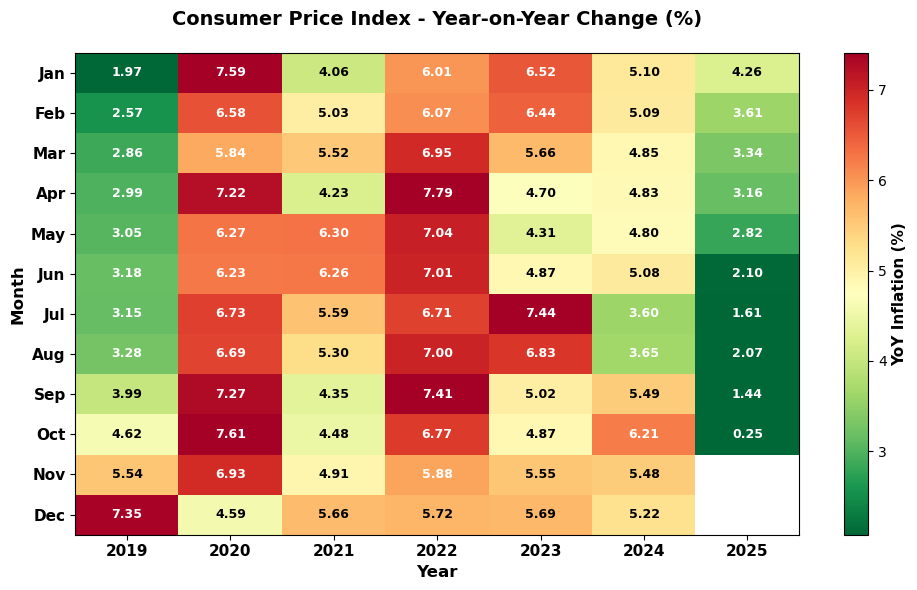

In [14]:
#| echo: false
#| warning: false
#| fig-width: 10
#| fig-height: 6
#| label: fig-yoy-heatmap
#| fig-cap: "Consumer Price Index - Year-on-Year Change Heatmap"

# Calculate YoY and MoM on the full dataframe first
df['CPI_YoY'] = df['Consumer Price Index'].pct_change(12) * 100
df['CPI_MoM'] = df['Consumer Price Index'].pct_change(1) * 100

# Filter data for the last 7 years
current_year = df['Year'].max()
df_last_7_years = df[df['Year'] >= current_year - 6].copy()

# Create pivot table for YoY heatmap
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

yoy_pivot = df_last_7_years.pivot_table(
    values='CPI_YoY', 
    index='Month', 
    columns='Year',
    aggfunc='first'
)

# Reindex to ensure all 12 months
yoy_pivot = yoy_pivot.reindex(index=range(1, 13))

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(10, 6))
vals = yoy_pivot.values

# Dynamic color scaling based on percentiles
finite_vals = vals[np.isfinite(vals)]
if finite_vals.size > 0:
    vmin = np.nanpercentile(finite_vals, 5)
    vmax = np.nanpercentile(finite_vals, 95)
else:
    vmin, vmax = -5, 5

# Create heatmap
im = ax.imshow(vals, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)

# Set ticks and labels
ax.set_xticks(range(yoy_pivot.shape[1]))
ax.set_xticklabels(yoy_pivot.columns.astype(str), fontweight='bold', fontsize=11)
ax.set_yticks(range(12))
ax.set_yticklabels(month_labels, fontweight='bold', fontsize=11)
ax.set_xlabel('Year', fontweight='bold', fontsize=12)
ax.set_ylabel('Month', fontweight='bold', fontsize=12)
ax.set_title('Consumer Price Index - Year-on-Year Change (%)', 
             fontweight='bold', fontsize=14, pad=20)

# Annotate cells with values
for i in range(yoy_pivot.shape[0]):
    for j in range(yoy_pivot.shape[1]):
        val = yoy_pivot.values[i, j]
        if not np.isnan(val):
            # Adaptive text color for readability
            color_intensity = (val - vmin) / (vmax - vmin) if vmax != vmin else 0.5
            text_color = 'white' if color_intensity < 0.3 or color_intensity > 0.7 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                   fontsize=9, color=text_color, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('YoY Inflation (%)', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

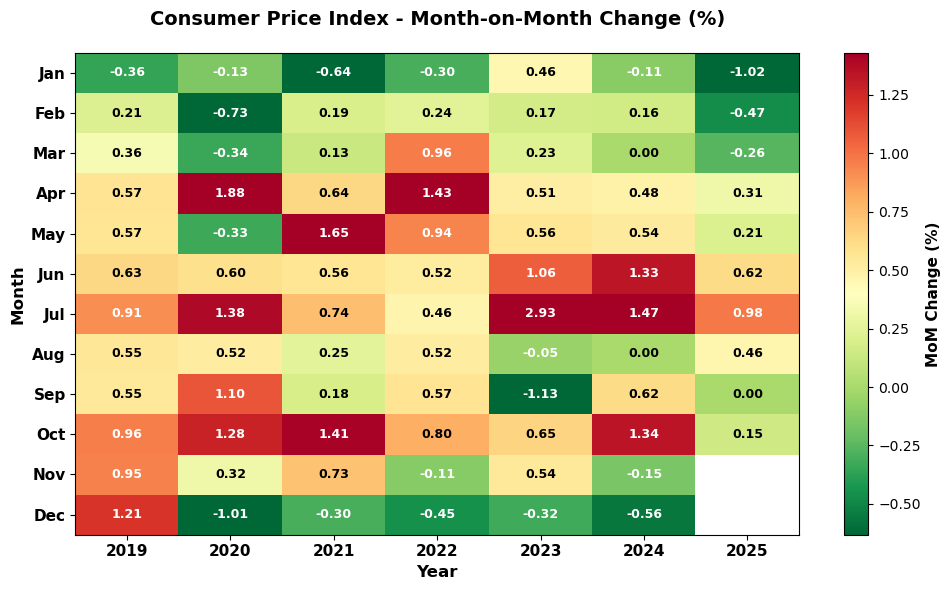

In [15]:
# Create pivot table for MoM heatmap (using data already calculated from full df)
mom_pivot = df_last_7_years.pivot_table(
    values='CPI_MoM', 
    index='Month', 
    columns='Year',
    aggfunc='first'
)

# Reindex to ensure all 12 months
mom_pivot = mom_pivot.reindex(index=range(1, 13))

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(10, 6))
vals = mom_pivot.values

# Dynamic color scaling based on percentiles
finite_vals = vals[np.isfinite(vals)]
if finite_vals.size > 0:
    vmin = np.nanpercentile(finite_vals, 5)
    vmax = np.nanpercentile(finite_vals, 95)
else:
    vmin, vmax = -2, 2

# Create heatmap
im = ax.imshow(vals, aspect='auto', cmap='RdYlGn_r', vmin=vmin, vmax=vmax)

# Set ticks and labels
ax.set_xticks(range(mom_pivot.shape[1]))
ax.set_xticklabels(mom_pivot.columns.astype(str), fontweight='bold', fontsize=11)
ax.set_yticks(range(12))
ax.set_yticklabels(month_labels, fontweight='bold', fontsize=11)
ax.set_xlabel('Year', fontweight='bold', fontsize=12)
ax.set_ylabel('Month', fontweight='bold', fontsize=12)
ax.set_title('Consumer Price Index - Month-on-Month Change (%)', 
             fontweight='bold', fontsize=14, pad=20)

# Annotate cells with values
for i in range(mom_pivot.shape[0]):
    for j in range(mom_pivot.shape[1]):
        val = mom_pivot.values[i, j]
        if not np.isnan(val):
            # Adaptive text color for readability
            color_intensity = (val - vmin) / (vmax - vmin) if vmax != vmin else 0.5
            text_color = 'white' if color_intensity < 0.3 or color_intensity > 0.7 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                   fontsize=9, color=text_color, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('MoM Change (%)', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [16]:
 #Define major CPI categories and their column names
category_mapping = {
    'Food & Beverages': 'Consumer Price Index: Food and Beverages',
    'Pan, Tobacco & Intox': 'Consumer Price Index: Pan, Tobacco and Intoxicants',
    'Clothing & Footwear': 'Consumer Price Index: Clothing and Footwear',
    'Housing': 'Consumer Price Index: Housing',
    'Fuel & Light': 'Consumer Price Index: Fuel and Light',
    'Miscellaneous': 'Consumer Price Index: Miscellaneous'
}

# Calculate YoY% for each category
for short_name, col_name in category_mapping.items():
    if col_name in df.columns:
        df[f'{short_name}_YoY'] = df[col_name].pct_change(12) * 100

# Filter to last 3 years for clearer visualization
current_year_cat = df['Year'].max()
df_categories = df[df['Year'] >= current_year_cat - 2].copy()

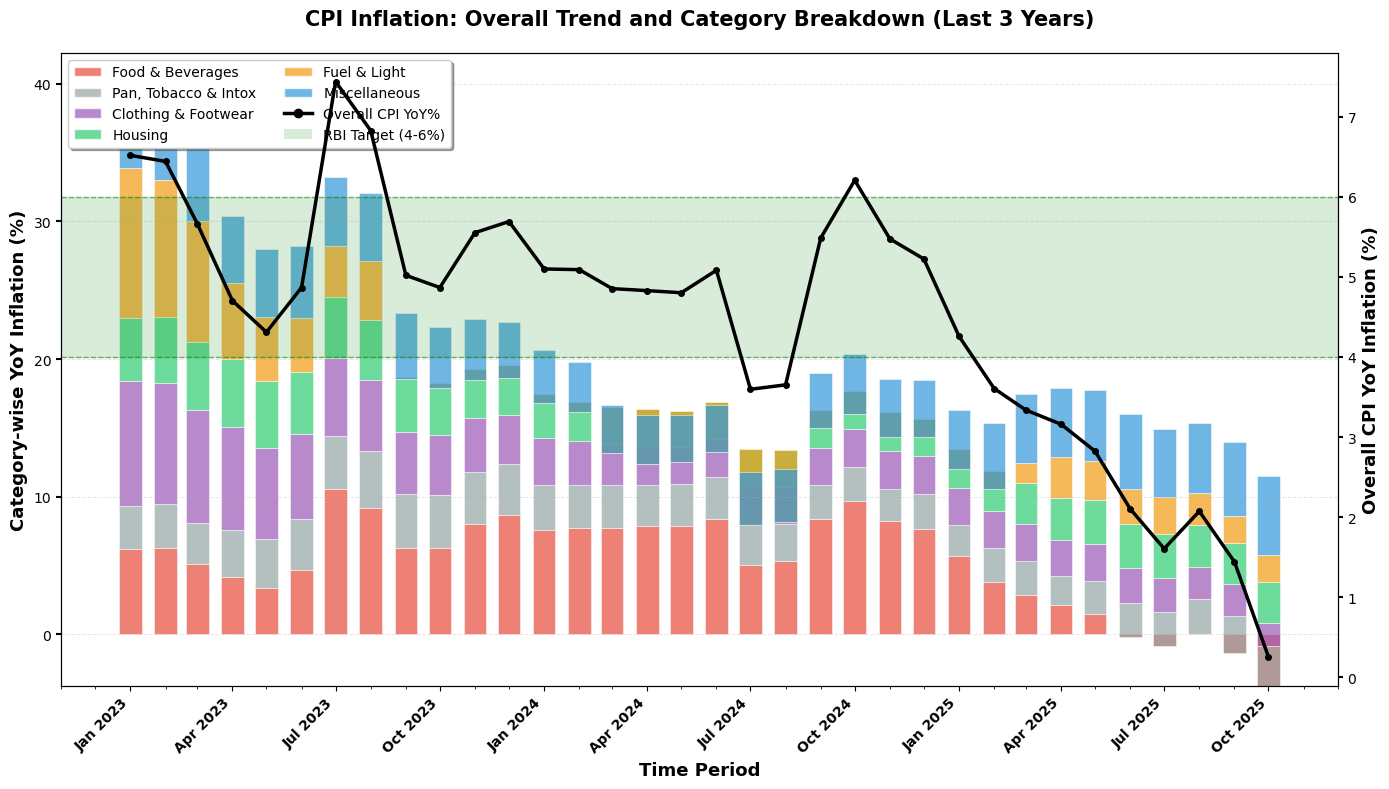

In [17]:
# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 8))

# Prepare data for stacked bars - using index values (normalized to 100 in base period)
# We'll show the relative levels of each category
bar_width = 20  # days width for bars
x_positions = df_categories['time']

# Define colors for categories
category_colors = {
    'Food & Beverages': '#e74c3c',
    'Miscellaneous': '#3498db',
    'Housing': '#2ecc71',
    'Fuel & Light': '#f39c12',
    'Clothing & Footwear': '#9b59b6',
    'Pan, Tobacco & Intox': '#95a5a6'
}

# Create stacked bars with YoY values
bottom = np.zeros(len(df_categories))
bar_handles = []

for short_name in category_mapping.keys():
    yoy_col = f'{short_name}_YoY'
    if yoy_col in df_categories.columns:
        values = df_categories[yoy_col].fillna(0).values
        bars = ax1.bar(x_positions, values, width=bar_width, bottom=bottom, 
                       label=short_name, color=category_colors[short_name], 
                       alpha=0.7, edgecolor='white', linewidth=0.5)
        bar_handles.append(bars)
        bottom += values

# Create secondary y-axis for the line chart
ax2 = ax1.twinx()

# Plot overall CPI YoY as a line on secondary axis
line = ax2.plot(df_categories['time'], df_categories['CPI_YoY'], 
                color='black', linewidth=2.5, marker='o', markersize=4,
                label='Overall CPI YoY%', zorder=10)

# Add RBI target band shading on secondary axis
ax2.axhspan(4, 6, alpha=0.15, color='green', zorder=0, label='RBI Target (4-6%)')
ax2.axhline(y=4, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=6, color='green', linestyle='--', linewidth=1, alpha=0.5)

# Formatting
ax1.set_xlabel('Time Period', fontweight='bold', fontsize=13)
ax1.set_ylabel('Category-wise YoY Inflation (%)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Overall CPI YoY Inflation (%)', fontweight='bold', fontsize=13, color='black')

ax1.set_title('CPI Inflation: Overall Trend and Category Breakdown (Last 3 Years)', 
              fontweight='bold', fontsize=15, pad=20)

# Grid
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.7, axis='y')
ax2.grid(False)

# Format x-axis
import matplotlib.dates as mdates
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', fontweight='bold')

# Y-axis formatting
ax1.tick_params(axis='y', labelcolor='black', labelsize=10, width=1.5)
ax2.tick_params(axis='y', labelcolor='black', labelsize=10, width=1.5)

# Combine legends
bars_legend = [plt.Rectangle((0,0),1,1, fc=category_colors[name], alpha=0.7, edgecolor='white') 
               for name in category_mapping.keys()]
line_legend = [plt.Line2D([0], [0], color='black', linewidth=2.5, marker='o', markersize=6)]
target_legend = [plt.Rectangle((0,0),1,1, fc='green', alpha=0.15)]

all_handles = bars_legend + line_legend + target_legend
all_labels = list(category_mapping.keys()) + ['Overall CPI YoY%', 'RBI Target (4-6%)']

ax1.legend(all_handles, all_labels, loc='upper left', fontsize=10, 
           frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.show()